In [1]:
# Autoreload imported modules when running a cell so we don't have to
# restart the notebook as often
%load_ext autoreload
%autoreload 2
# Display plots in an interactive way. widget works well with vscode
%matplotlib widget

In [2]:
from simulations.envelope import a_d_envelope, TIME_END, TIME_START, EnvelopeSettings
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import ipywidgets as widgets  # pyright: ignore[reportMissingTypeStubs]

def settings_label(s: EnvelopeSettings) -> str:
    return f"a={s.attack}, d={s.decay}, s={s.shape}, amp={s.amplitude}"


T_MAX = TIME_END * 2.7
TIMES = np.linspace(TIME_START, T_MAX, 1000)

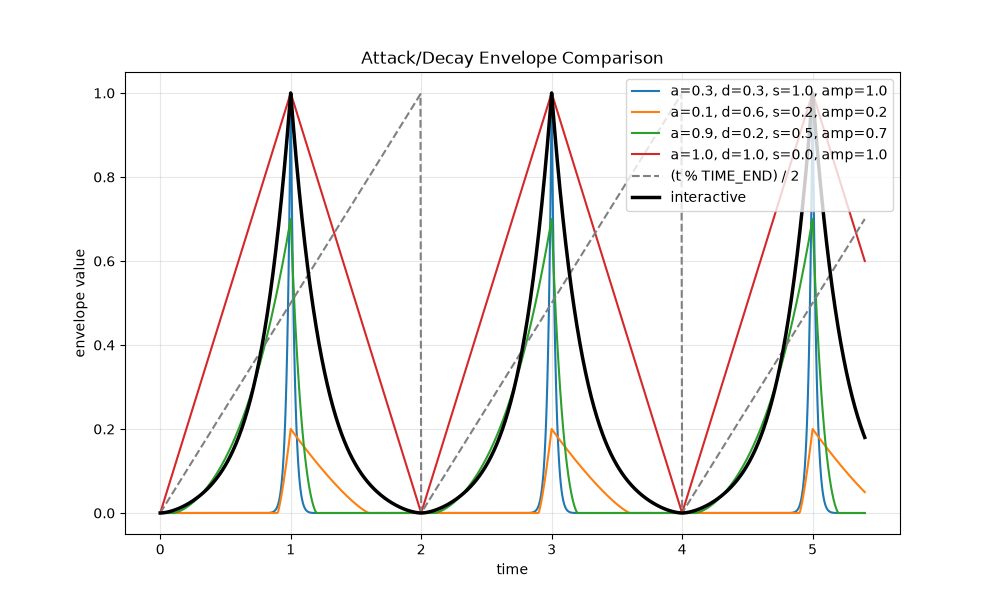

In [ ]:
# Show how a single envelope is synthesized and how the position of its peak does not depend on its input parameters
fixed_envelopes = [
    EnvelopeSettings(attack=0.3, decay=0.3, shape=1.0, amplitude=1.0),
    EnvelopeSettings(attack=0.1, decay=0.6, shape=0.2, amplitude=0.2),
    EnvelopeSettings(attack=0.9, decay=0.2, shape=0.5, amplitude=0.7),
    EnvelopeSettings(attack=1.0, decay=1.0, shape=0.0, amplitude=1.0),
]

fig, ax = plt.subplots(figsize=(10, 6))

fixed_lines: list[Line2D] = []
for envelope in fixed_envelopes:
    values = [a_d_envelope(envelope, t % TIME_END) for t in TIMES]
    line, = ax.plot(TIMES, values, label=settings_label(envelope))
    fixed_lines.append(line)

# Reference line: (t % TIME_END) / 2
ref_line, = ax.plot(TIMES, [(t % TIME_END) / 2 for t in TIMES],
                       label="(t % TIME_END) / 2", linestyle="--", color="gray")

# Interactive envelope
interactive_settings = EnvelopeSettings(attack=1.0, decay=1.0, shape=0.7, amplitude=1.0)
interactive_values = [a_d_envelope(interactive_settings, t % TIME_END) for t in TIMES]
interactive_line, = ax.plot(TIMES, interactive_values, label="interactive", linewidth=2.5, color="black")


ax.set_xlabel("time")
ax.set_ylabel("envelope value")
ax.set_title("Attack/Decay Envelope Comparison")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Widgets
attack_slider = widgets.FloatSlider(value=interactive_settings.attack, min=0.0, max=1.0, step=0.01, description="attack")
decay_slider  = widgets.FloatSlider(value=interactive_settings.decay, min=0.0, max=1.0, step=0.01, description="decay")
shape_slider  = widgets.FloatSlider(value=interactive_settings.shape, min=0.0, max=1.0, step=0.01, description="shape")
amp_slider    = widgets.FloatSlider(value=interactive_settings.amplitude, min=0.0, max=1.0, step=0.01, description="amplitude")
fixed_checkbox = widgets.Checkbox(value=True, description="fixed envelopes")


# Callbacks
def update_interactive_line(*_):
    settings = EnvelopeSettings(
        attack=attack_slider.value,
        decay=decay_slider.value,
        shape=shape_slider.value,
        amplitude=amp_slider.value,
    )
    values = [a_d_envelope(settings, t % TIME_END) for t in TIMES]
    interactive_line.set_ydata(values)
    fig.canvas.draw_idle()

def update_fixed_visibility(change: dict[str, bool]):
    for line in fixed_lines:
        line.set_visible(change["new"])
    fig.canvas.draw_idle()

# Hook up interactive inputs changes
for slider in (attack_slider, decay_slider, shape_slider, amp_slider):
    slider.observe(update_interactive_line, names="value")
fixed_checkbox.observe(update_fixed_visibility, names="value")

# Layout
controls = widgets.HBox([
    widgets.VBox([attack_slider, decay_slider, shape_slider, amp_slider,]),
    fixed_checkbox,
])

display(controls)


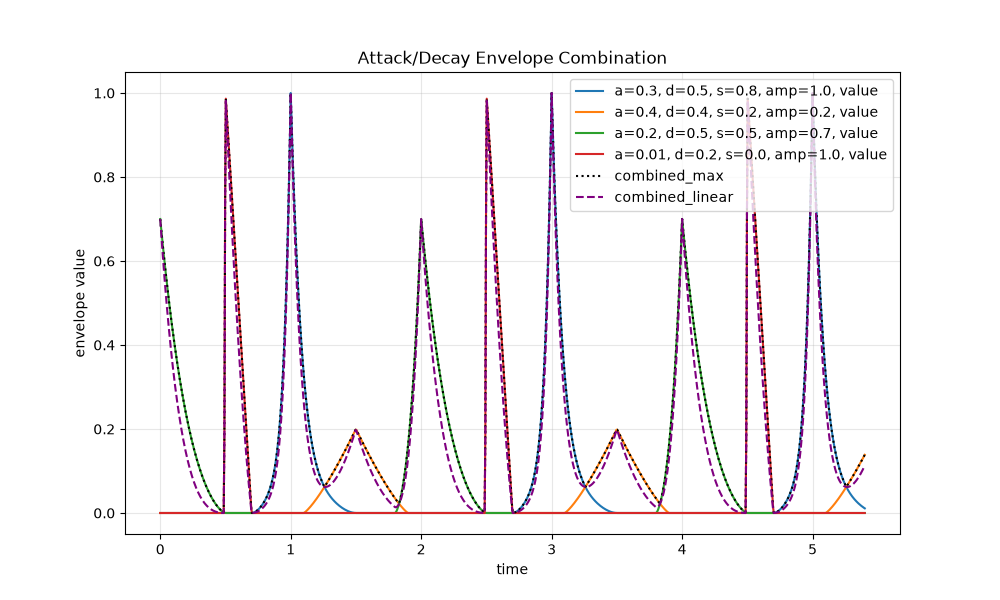

In [4]:
from simulations.envelope import EnvelopeStatus, combine_envelopes, combine_interpolate_linear, combine_max, offset_envelopes


fixed_envelopes = [
    EnvelopeSettings(attack=0.3, decay=0.5, shape=0.8, amplitude=1.0),
    EnvelopeSettings(attack=0.4, decay=0.4, shape=0.2, amplitude=0.2),
    EnvelopeSettings(attack=0.2, decay=0.5, shape=0.5, amplitude=0.7),
    EnvelopeSettings(attack=0.01, decay=0.2, shape=0.0, amplitude=1.0),
]

plt.figure(figsize=(10, 6))

offset_values = [
    offset_envelopes(fixed_envelopes, t % TIME_END)
    for t in TIMES
]
values_combined_max = [
    combine_envelopes(s, combine_max)
    for s in offset_values
]
values_combined_linear = [
    combine_envelopes(s, combine_interpolate_linear)
    for s in offset_values
]
samples_per_envelope: list[list[EnvelopeStatus]] = [[] for _ in fixed_envelopes]
for sample in offset_values:
    for i, env in enumerate(sample):
        samples_per_envelope[i].append(env)

for i, samples in enumerate(samples_per_envelope):
    plt.plot(TIMES, [s.value for s in samples], label=f"{settings_label(fixed_envelopes[i])}, value")

plt.plot(TIMES, values_combined_max, label="combined_max", linestyle=":", color="black")
plt.plot(TIMES, values_combined_linear, label="combined_linear", linestyle="--", color="purple")

plt.xlabel("time")
plt.ylabel("envelope value")
plt.title("Attack/Decay Envelope Combination")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()